# 绘图
下面的代码主要是为了绘图，也就是paper里面的一些图都是这里生成的，


## 仿真地点演示图
这里主要是演示仿真中，地面站/用户的分布。
中国：
| 地点           | 纬度 (Latitude)  | 经度 (Longitude)  |
| ------------ | -------------- | --------------- |
| 北京           | **39.9042° N** | **116.4074° E** |
| 重庆           | **29.5630° N** | **106.5516° E** |
| 黑龙江（哈尔滨市，省会） | **45.8038° N** | **126.5350° E** |
| 新疆（乌鲁木齐市，首府） | **43.8256° N** | **87.6168° E**  |
| 海南（海口市，省会）   | **20.0442° N** | **110.1999° E** |



欧洲：
| 国家  | 首都            | 纬度 (Latitude)  | 经度 (Longitude) |
| --- | ------------- | -------------- | -------------- |
| 德国  | 柏林 Berlin     | **52.5200° N** | **13.4050° E** |
| 波兰  | 华沙 Warsaw     | **52.2297° N** | **21.0122° E** |
| 法国  | 巴黎 Paris      | **48.8566° N** | **2.3522° E**  |
| 西班牙 | 马德里 Madrid    | **40.4168° N** | **-3.7038° W** |
| 意大利 | 罗马 Rome       | **41.9028° N** | **12.4964° E** |
| 匈牙利 | 布达佩斯 Budapest | **47.4979° N** | **19.0402° E** |


In [1]:
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 5), facecolor="white")
proj = ccrs.PlateCarree()

ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_global()
ax.set_frame_on(False)

for side in ["top", "right", "bottom", "left"]:
    if side in ax.spines:
        ax.spines[side].set_visible(False)

if "geo" in ax.spines:
    ax.spines["geo"].set_visible(False)

ax.patch.set_edgecolor("none")
fig.patch.set_edgecolor("none")

# =========================
# 配色（参考第二张图）
# =========================
ocean_fc = "#FFFFFF"   # 海洋/背景：白色
land_fc  = "#BBBBBB"   # 陆地：浅灰色
coast_ec = "#D0D0D0"   # 海岸线：非常淡的灰

ax.set_facecolor(ocean_fc)

# 海洋
ax.add_feature(
    cfeature.OCEAN.with_scale("110m"),
    facecolor=ocean_fc,
    edgecolor="none",
    zorder=0
)

# 陆地
ax.add_feature(
    cfeature.LAND.with_scale("110m"),
    facecolor=land_fc,
    edgecolor="none",
    zorder=1
)

# 湖泊也白色，避免陆地里出现奇怪的蓝块
ax.add_feature(
    cfeature.LAKES.with_scale("110m"),
    facecolor=ocean_fc,
    edgecolor="none",
    zorder=2
)

# =========================
# 地面用户点（数据顺序均为 (lat, lon)）
# =========================
china_points = [
    (30, 84), (19, 110), (22, 102), (27, 98), (25, 118),
    (34, 119), (41, 126), (48, 126), (36, 114), (36, 102),
    (36, 90), (36, 78),
]

europe_points = [
    (43, 3.75), (52, 12), (46, 12), (46, 4.4), (47, -0.4),
    (41.8, 13.6), (39.6, -5), (59.8, 13.4), (54, -1.6),
]

# 北美(人口/通信热点,10点)
north_america_points = [
    (40.71, -74.01),    # New York
    (34.05, -118.24),   # Los Angeles
    (41.88, -87.63),    # Chicago
    (43.65, -79.38),    # Toronto
    (32.78, -96.80),    # Dallas
    (37.77, -122.42),   # San Francisco
    (19.43, -99.13),    # Mexico City
    (25.76, -80.19),    # Miami
    (47.61, -122.33),   # Seattle
    (38.91, -77.04),    # Washington DC
]

# 非洲(人口/通信热点,8点)
africa_points = [
    (30.04, 31.24),     # Cairo
    (6.52, 3.38),       # Lagos
    (-26.20, 28.05),    # Johannesburg
    (-1.29, 36.82),     # Nairobi
    (33.57, -7.59),     # Casablanca
    (-4.32, 15.31),     # Kinshasa
    (9.03, 38.74),      # Addis Ababa
    (5.60, -0.19),      # Accra
]

# 南美(人口/通信热点,4点;若"美洲"只要北美则删掉此组)
south_america_points = [
    (-23.55, -46.63),   # Sao Paulo
    (-34.60, -58.38),   # Buenos Aires
    (4.71, -74.07),     # Bogota
    (-12.05, -77.04),   # Lima
]

# =========================
# 拆分经纬度
# =========================
def split_lonlat(points):
    lons = [lon for lat, lon in points]
    lats = [lat for lat, lon in points]
    return lons, lats

china_lons, china_lats = split_lonlat(china_points)
europe_lons, europe_lats = split_lonlat(europe_points)
na_lons, na_lats = split_lonlat(north_america_points)
af_lons, af_lats = split_lonlat(africa_points)
sa_lons, sa_lats = split_lonlat(south_america_points)

# =========================
# 各区域配色（低饱和、可区分）
# =========================
china_color  = "#DC143C"   # 红
europe_color = "#4C78A8"   # 蓝
na_color     = "#59A14F"   # 绿(北美)
af_color     = "#E6952B"   # 橙(非洲)
sa_color     = "#9467BD"   # 紫(南美)

# 把所有区域放一起，统一画 halo + 主圆，避免重复代码
regions = [
    (china_lons,  china_lats,  china_color),
    (europe_lons, europe_lats, europe_color),
    (na_lons,     na_lats,     na_color),
    (af_lons,     af_lats,     af_color),
    (sa_lons,     sa_lats,     sa_color),
]

# 先画白色 halo（外层）
for lons, lats, _ in regions:
    ax.scatter(
        lons, lats,
        s=58, marker="o",
        facecolors="white", edgecolors="white",
        linewidths=0.0, zorder=4,
        transform=ccrs.PlateCarree(),
    )

# 再画彩色主圆（内层）
for lons, lats, color in regions:
    ax.scatter(
        lons, lats,
        s=28, marker="o",
        facecolors=color, edgecolors="#444444",
        linewidths=0.35, zorder=5,
        transform=ccrs.PlateCarree(),
    )

# 海岸线压在最上层
ax.coastlines(
    resolution="110m",
    color=coast_ec,
    linewidth=0.25,
    zorder=3
)

plt.tight_layout()

# =========================
# 导出
# =========================
fig.savefig("world_users_map.pdf", bbox_inches="tight")
fig.savefig("world_users_map.svg", bbox_inches="tight")
fig.savefig("world_users_map.png", dpi=300, bbox_inches="tight")

plt.show()

ModuleNotFoundError: No module named 'cartopy'

上面的图是参考
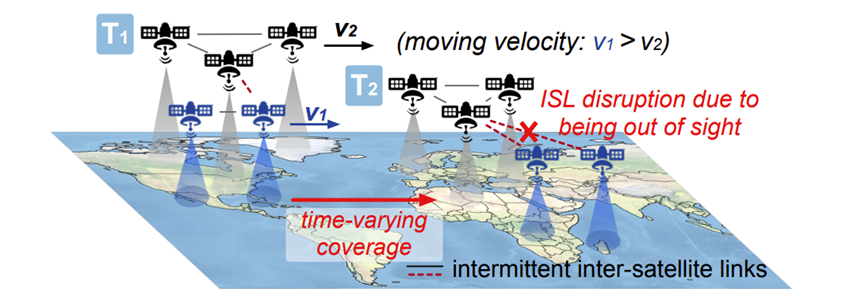

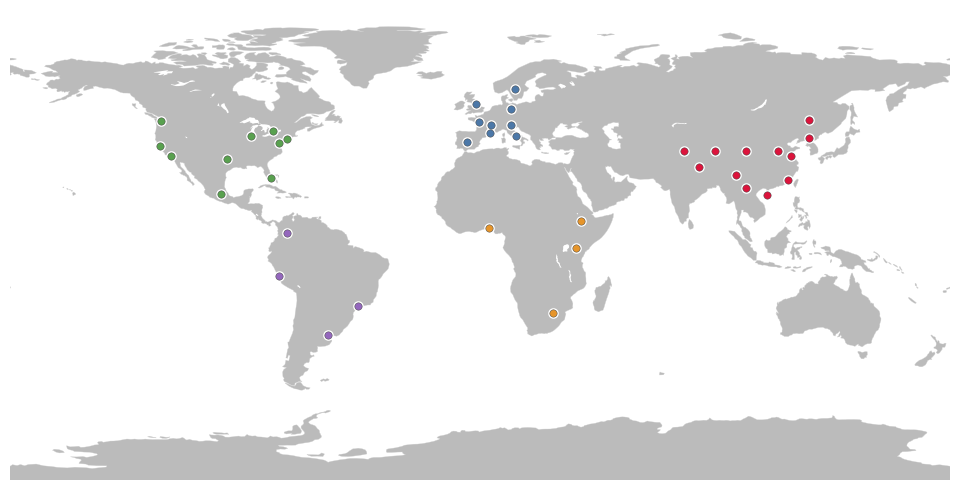

In [4]:
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 5), facecolor="white")
proj = ccrs.PlateCarree()

ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_global()
ax.set_frame_on(False)

for side in ["top", "right", "bottom", "left"]:
    if side in ax.spines:
        ax.spines[side].set_visible(False)

if "geo" in ax.spines:
    ax.spines["geo"].set_visible(False)

ax.patch.set_edgecolor("none")
fig.patch.set_edgecolor("none")

# =========================
# 配色
# =========================
ocean_fc = "#FFFFFF"   # 海洋/背景：白色
land_fc  = "#BBBBBB"   # 陆地：浅灰色
coast_ec = "#D0D0D0"   # 海岸线：非常淡的灰

ax.set_facecolor(ocean_fc)

ax.add_feature(
    cfeature.OCEAN.with_scale("110m"),
    facecolor=ocean_fc, edgecolor="none", zorder=0
)
ax.add_feature(
    cfeature.LAND.with_scale("110m"),
    facecolor=land_fc, edgecolor="none", zorder=1
)
ax.add_feature(
    cfeature.LAKES.with_scale("110m"),
    facecolor=ocean_fc, edgecolor="none", zorder=2
)

# =========================
# 地面用户点（数据顺序均为 (lat, lon)）
# =========================
china_points = [
    (30, 84), (19, 110), (22, 102), (27, 98), (25, 118),
    (34, 119), (41, 126), (48, 126), (36, 114), (36, 102),
    (36, 90), (36, 78),
]

europe_points = [
    (43, 3.75), (52, 12), (46, 12), (46, 4.4), (47, -0.4),
    (41.8, 13.6), (39.6, -5), (59.8, 13.4), (54, -1.6),
]

# 北美(人口/通信热点,10点)
north_america_points = [
    (40.71, -74.01),    # New York
    (34.05, -118.24),   # Los Angeles
    (41.88, -87.63),    # Chicago
    (43.65, -79.38),    # Toronto
    (32.78, -96.80),    # Dallas
    (37.77, -122.42),   # San Francisco
    (19.43, -99.13),    # Mexico City
    (25.76, -80.19),    # Miami
    (47.61, -122.33),   # Seattle
    (38.91, -77.04),    # Washington DC
]

# 非洲(人口/通信热点,4点)
africa_points = [
    (6.52, 3.38),       # Lagos, Nigeria
    (-26.20, 28.05),    # Johannesburg, South Africa
    (-1.29, 36.82),     # Nairobi, Kenya
    (9.03, 38.74),      # Addis Ababa, Ethiopia
]

# 南美(人口/通信热点,4点;若"美洲"只要北美则删掉此组)
south_america_points = [
    (-23.55, -46.63),   # Sao Paulo
    (-34.60, -58.38),   # Buenos Aires
    (4.71, -74.07),     # Bogota
    (-12.05, -77.04),   # Lima
]

# =========================
# 拆分经纬度
# =========================
def split_lonlat(points):
    lons = [lon for lat, lon in points]
    lats = [lat for lat, lon in points]
    return lons, lats

china_lons, china_lats = split_lonlat(china_points)
europe_lons, europe_lats = split_lonlat(europe_points)
na_lons, na_lats = split_lonlat(north_america_points)
af_lons, af_lats = split_lonlat(africa_points)
sa_lons, sa_lats = split_lonlat(south_america_points)

# =========================
# 各区域配色
# =========================
china_color  = "#DC143C"   # 红
europe_color = "#4C78A8"   # 蓝
na_color     = "#59A14F"   # 绿(北美)
af_color     = "#E6952B"   # 橙(非洲)
sa_color     = "#9467BD"   # 紫(南美)

regions = [
    (china_lons,  china_lats,  china_color),
    (europe_lons, europe_lats, europe_color),
    (na_lons,     na_lats,     na_color),
    (af_lons,     af_lats,     af_color),
    (sa_lons,     sa_lats,     sa_color),
]

# 先画白色 halo（外层）
for lons, lats, _ in regions:
    ax.scatter(
        lons, lats,
        s=58, marker="o",
        facecolors="white", edgecolors="white",
        linewidths=0.0, zorder=4,
        transform=ccrs.PlateCarree(),
    )

# 再画彩色主圆（内层）
for lons, lats, color in regions:
    ax.scatter(
        lons, lats,
        s=28, marker="o",
        facecolors=color, edgecolors="#444444",
        linewidths=0.35, zorder=5,
        transform=ccrs.PlateCarree(),
    )

# 海岸线压在最上层
ax.coastlines(
    resolution="110m",
    color=coast_ec,
    linewidth=0.25,
    zorder=3
)

plt.tight_layout()

# =========================
# 导出
# =========================
fig.savefig("world_users_map.pdf", bbox_inches="tight")
fig.savefig("world_users_map.svg", bbox_inches="tight")
fig.savefig("world_users_map.png", dpi=300, bbox_inches="tight")

plt.show()

In [5]:
import math
import os

# WGS84 椭球参数
a = 6378137.0
f = 1 / 298.257223563
e2 = f * (2 - f)


def geo2ecef(lat_deg, lon_deg, h=0.0):
    """
    经纬度(度) + 高程(米) -> ECEF 地固地心坐标 (X, Y, Z)，单位米。
    约定：东经为正、西经为负；北纬为正、南纬为负。
    """
    lat = math.radians(lat_deg)
    lon = math.radians(lon_deg)
    N = a / math.sqrt(1 - e2 * math.sin(lat) ** 2)
    x = (N + h) * math.cos(lat) * math.cos(lon)
    y = (N + h) * math.cos(lat) * math.sin(lon)
    z = (N * (1 - e2) + h) * math.sin(lat)
    return x, y, z


def export_points_to_txt(points, outdir, start_index=1):
    """
    把一组 (lat, lon) 点转成 ECEF，每个点写一个 txt 文件。
    文件名为 1.txt, 2.txt, ...（从 start_index 开始连续编号）。
    每个 txt 内容：一行三个数，Tab 分隔，与 station 文件格式一致。
    返回下一个可用的编号（便于多组接续编号）。
    """
    os.makedirs(outdir, exist_ok=True)
    idx = start_index
    for lat, lon in points:
        x, y, z = geo2ecef(lat, lon, 0.0)
        fname = os.path.join(outdir, f"{idx}.txt")
        with open(fname, "w") as fp:
            fp.write(f"{x}\t{y}\t{z}\n")
        idx += 1
    return idx


# ===== 地面点 (lat, lon) =====
china_points = [
    (30, 84), (19, 110), (22, 102), (27, 98), (25, 118),
    (34, 119), (41, 126), (48, 126), (36, 114), (36, 102),
    (36, 90), (36, 78),
]
europe_points = [
    (43, 3.75), (52, 12), (46, 12), (46, 4.4), (47, -0.4),
    (41.8, 13.6), (39.6, -5), (59.8, 13.4), (54, -1.6),
]
north_america_points = [
    (40.71, -74.01), (34.05, -118.24), (41.88, -87.63), (43.65, -79.38),
    (32.78, -96.80), (37.77, -122.42), (19.43, -99.13), (25.76, -80.19),
    (47.61, -122.33), (38.91, -77.04),
]
africa_points = [
    (6.52, 3.38), (-26.20, 28.05), (-1.29, 36.82), (9.03, 38.74),
]
south_america_points = [
    (-23.55, -46.63), (-34.60, -58.38), (4.71, -74.07), (-12.05, -77.04),
]


if __name__ == "__main__":
    outdir = "ground_nodes_ecef"   # 输出目录，按需修改

    # 按顺序：中国 -> 欧洲 -> 北美 -> 非洲 -> 南美，连续编号
    next_idx = 1
    next_idx = export_points_to_txt(china_points,         outdir, next_idx)
    next_idx = export_points_to_txt(europe_points,        outdir, next_idx)
    next_idx = export_points_to_txt(north_america_points, outdir, next_idx)
    next_idx = export_points_to_txt(africa_points,        outdir, next_idx)
    next_idx = export_points_to_txt(south_america_points, outdir, next_idx)

    print(f"完成，共导出 {next_idx - 1} 个 txt 到目录: {outdir}")

完成，共导出 39 个 txt 到目录: ground_nodes_ecef
